In [1]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import joblib
from PIL import Image

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH = 32

train_dir = "C:/Fruit_fresh_pro/dataset_split/train/apple"
val_dir = "C:/Fruit_fresh_pro/dataset_split/val/apple"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="int"
)

NUM_CLASSES = len(train_ds.class_names)

# Normalize
train_ds = train_ds.map(lambda x, y: (x/255.0, y)).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x/255.0, y)).prefetch(tf.data.AUTOTUNE)


Found 2600 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


In [3]:
inputs = layers.Input(shape=(128,128,3))

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2))(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)

x = layers.GlobalAveragePooling2D()(x)

feature_layer = layers.Dense(128, activation='relu', name="feature_layer")(x)

# Temporary softmax for CNN training only
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(feature_layer)

cnn = models.Model(inputs, outputs)

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [4]:
history = cnn.fit(train_ds, 
                  validation_data=val_ds, 
                  epochs=10)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.8788 - loss: 0.2799 - val_accuracy: 0.5150 - val_loss: 0.7024
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 37s 441ms/step - accuracy: 0.9069 - loss: 0.2336 - val_accuracy: 0.5250 - val_loss: 0.8307
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 42s 447ms/step - accuracy: 0.9250 - loss: 0.1892 - val_accuracy: 0.5300 - val_loss: 1.4264
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 37s 450ms/step - accuracy: 0.9381 - loss: 0.1582 - val_accuracy: 0.5575 - val_loss: 1.5949
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 442ms/step - accuracy: 0.9419 - loss: 0.1568 - val_accuracy: 0.5900 - val_loss: 1.2391
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 37s 441ms/step - accuracy: 0.9531 - loss: 0.1243 - val_accuracy: 0.6375 - val_loss: 1.1259
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 37s 449ms/step - accuracy: 0.9631 - loss: 0.0989 - val_accuracy: 0.8675 - val_loss: 0.3308
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 37s 449ms/step - accuracy: 0.9546 - loss: 0.1157 - val_accu

In [5]:
cnn.save("C:/Fruit_Fresh_pro/model/apple_cnn.h5")

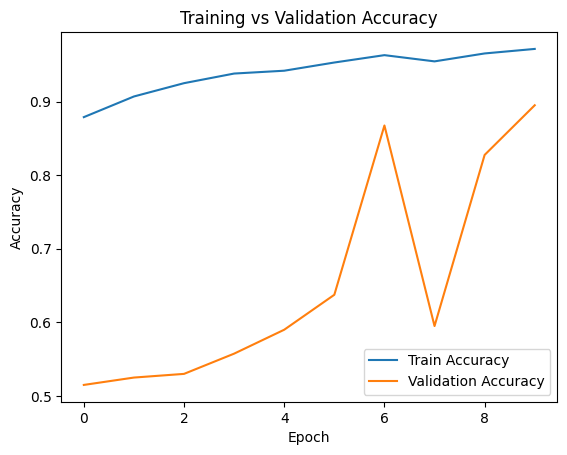

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

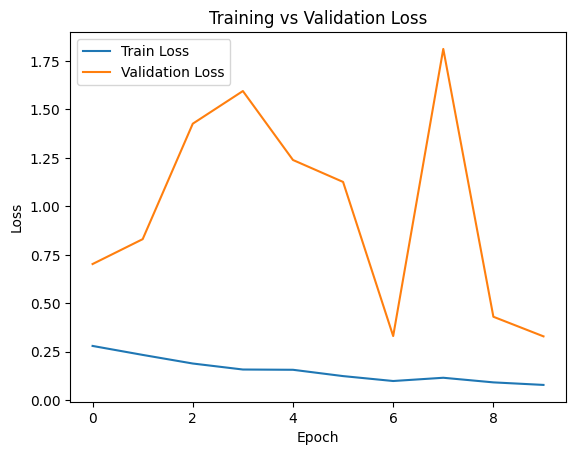

In [7]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [9]:
cnn.trainable = False

In [10]:
feature_model = models.Model(
    inputs=cnn.input,
    outputs=cnn.get_layer("feature_layer").output
)

def extract_features(dataset):
    features = []
    labels = []

    for images, y in dataset:
        f = feature_model.predict(images, verbose=0)
        features.append(f)
        labels.append(y.numpy())

    return np.vstack(features), np.hstack(labels)

X_train, y_train = extract_features(train_ds)
X_val, y_val = extract_features(val_ds)

In [11]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC())
])

svm.fit(X_train, y_train)
y_pred = svm.predict(X_val)

svm_acc = accuracy_score(y_val, y_pred)
print(f"SVM Accuracy: {svm_acc * 100:.2f}%")

SVM Accuracy: 97.00%


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix (SVM)")
print("Actual \\ Predicted")
print("Fresh   Rotten")
print(cm)

Confusion Matrix (SVM)
Actual \ Predicted
Fresh   Rotten
[[194   6]
 [  6 194]]


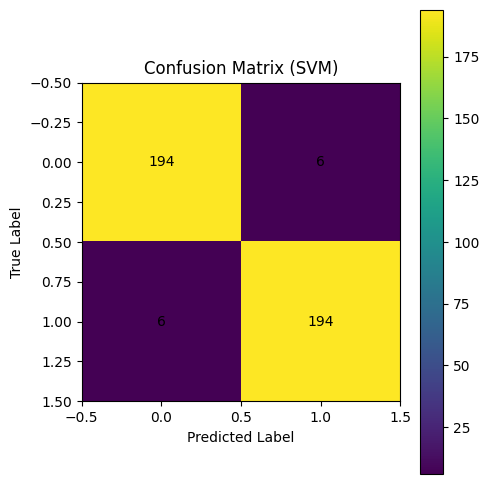

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

In [14]:
from joblib import dump

# svm_model = your trained SVM
dump(svm, "C:/Fruit_Fresh_pro/model/apple_svm.pkl")

print("SVM model saved successfully!")

SVM model saved successfully!


In [15]:
from joblib import load

svm_model = load("C:/Fruit_Fresh_pro/model/apple_svm.pkl")

print("SVM model loaded successfully!")

SVM model loaded successfully!


In [16]:
from PIL import Image
import numpy as np

def extract_features_from_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((128,128))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    # ✅ Use feature_model, NOT extract_features()
    features = feature_model.predict(img)

    return features

In [19]:
img_path = r"C:/Fruit_Fresh_pro/random/random_apple/360_F_82489893_jLN78Amb8ei8gjLYP56EhWoNN9ELfFWF.jpg"

features = extract_features_from_image(img_path)
print(features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
(1, 128)


In [20]:
prediction = svm.predict(features)
print(prediction)

[1]


In [22]:
random_folder = r"C:/Fruit_Fresh_pro/random/random_apple/"

for file in os.listdir(random_folder):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(random_folder, file)

        # 1️⃣ Extract CNN features
        features = extract_features_from_image(img_path)
        print(f"{file} → feature shape:", features.shape)

        # 3️⃣ SVM prediction
        prediction = svm.predict(features)[0]

        # 4️⃣ Print result
        print(f"{file} → Predicted class: {prediction}")
        print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
360_F_82489893_jLN78Amb8ei8gjLYP56EhWoNN9ELfFWF.jpg → feature shape: (1, 128)
360_F_82489893_jLN78Amb8ei8gjLYP56EhWoNN9ELfFWF.jpg → Predicted class: 1
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
4f6cc46e50e7a0ff21c5e0a77423b0b5.jpg → feature shape: (1, 128)
4f6cc46e50e7a0ff21c5e0a77423b0b5.jpg → Predicted class: 0
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
images.jpg → feature shape: (1, 128)
images.jpg → Predicted class: 1
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
pngtree-one-red-apple-with-water-drops-apple-png-image_9936621.png → feature shape: (1, 128)
pngtree-one-red-apple-with-water-drops-apple-png-image_9936621.png → Predicted class: 0
--------------------------------------------------
